# Problem 2: Water Waves
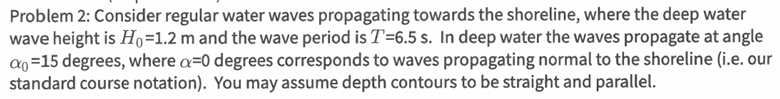

In [3]:
import numpy as np
import sympy as sp
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
from matplotlib import animation

In [4]:
H_0 = 1.2                   # Deep water wave height [m]
T = 6.5                     # Wave period [s]
g = 9.81                    # Gravitational acceleration [m/s^2]
alpha_0 = 15 * np.pi/180    # Wave angle [rad] -> where alpha 0 corresponds to waves propagating normal to the shoreline

### Question 2.1
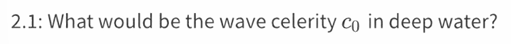

In [5]:
L_0 = g * T**2 / (2 * np.pi)                    # deep water wave length [m]
k_0 = 2 * np.pi / L_0                           # deep water wave number [m^-1]
c_0 = np.sqrt(g / k_0)                          # deep water wave celerity [m/s]

# ----------------
# Print results
# ----------------
print(f"Wave celerity: {c_0:.1f} m/s")

Wave celerity: 10.1 m/s


### Question 2.2
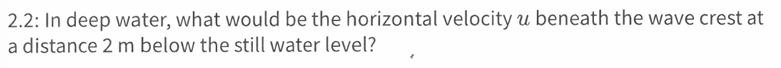

In [6]:
DEPTH = 2               # Water depth [m]
omega = 2 * np.pi / T   # Angular frequency [rad/s]

# Velocity at wave crest in deep water
u_at_y = lambda y: H_0/2 * omega * np.exp(-k_0 * y) 

# Print results
print(f"Maximum orbital velocity at the surface: {u_at_y(DEPTH):.2f} m/s")



Maximum orbital velocity at the surface: 0.48 m/s


### Question 2.3
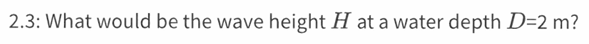

In [60]:
# ----------------------------------------------
# Functions to obtain wave height at deep water
# ----------------------------------------------

def Snell_law (alpha, alpha_0, k, k_0):                                    # Snell's law
    return np.sin(alpha)*k - np.sin(alpha_0)*k_0

def cons_energy_flux (H, H_0, k, D, alpha, alpha_0): #energy flux conservation with refraction
    G = 2*k*D / np.sinh(2*k*D)
    K_s = np.sqrt(1.0 /(np.tanh(k*D) * (1.0+G)))
    K_r = np.sqrt(np.cos(alpha_0)/np.cos(alpha))
    return H - H_0*K_r*K_s

def dispersion(k, D, T):                                                   # Dispersion relation
    omega = 2*np.pi/T
    return omega**2 - g * k * np.tanh(k*D)

def refraction(D, H_0, k_0, alpha_0, T):
    def system(x):
        H, k, alpha = x
        return np.array([cons_energy_flux(H, H_0, k, D, alpha, alpha_0),dispersion(k, D, T), Snell_law(alpha, alpha_0, k, k_0)], dtype=float)
    
    H, k, alpha = fsolve(system, x0=[H_0, k_0, alpha_0])
    return H, k, alpha


# Print the reults
H, k, alpha = refraction(DEPTH, H_0, k_0, alpha_0, T)
print(f"Wave height at D={DEPTH} m: {H:.2f} m")

Wave height at D=2 m: 1.33 m


### Question 2.4
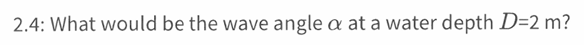

In [ ]:
# Print the reults
print(f"Wave angle at D={DEPTH} m: {alpha*180/np.pi:.1f} degrees")

Wave angle at D=2 m: 6.3 degrees


### Question 2.5
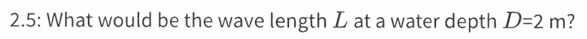

In [62]:
# Calculate wave length at D=2 m
L = lambda k: 2*np.pi/k

# Print the reults
print(f"Wave length at D={DEPTH} m: {L(k):.1f} m")

Wave length at D=2 m: 27.9 m


### Question 2.6
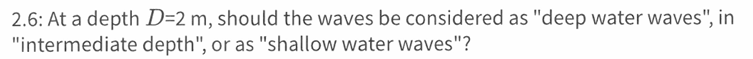

In [63]:
def water_condition(H, k, D):
    if k*D > np.pi:
        return "Deep water"
    elif k*D < np.pi/10:
        return "Shallow water"
    else:
        return "Intermediate water"
    
# Print the reults
print(f"Water condition at D={DEPTH} m: {water_condition(H, k, DEPTH)}")

Water condition at D=2 m: Intermediate water
